# MCD / YUM — DDQN Pairs Trading (v12)

Exact port of the XOM/CVX v4 approach to the McDonald's / Yum! Brands pair.

**Pipeline:**
1. **Sliding-window stationarity analysis** — 2-year windows stepped by 2 months. Each window is tested with ADF (p < 0.05), KPSS (p > 0.05), and half-life (5–252 days). An *effective beta* is computed for each day as the average OLS slope across all passing windows that cover it.
2. **Spread** — `log_MCD − β·log_YUM − intercept`, defined only where beta is active (all 3 tests pass). Johansen betas are shown for comparison but OLS is used for trading.
3. **Synthetic training episodes** — 200 real 18-month slices from stationary regions are fitted with AR(1) + GBM; 4 synthetic paths each → 800 unique episodes. The agent never trains directly on real prices.
4. **DDQN agent** — observes `[spread, z10, z45, z100, position]`. Beta is assumed known and used for position sizing. Positions are rebalanced (with TC) when beta changes. The position is force-closed when the pair leaves a stationary section. Cash earns 5% annualised when flat.
5. **Train/test split at 50 %** of the data — equal in-sample and out-of-sample periods.

In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from data_loader import PairData

data   = PairData('../../data/real_pair_MCD_YUM.csv')
prices = data.s          # shape (2, N)
labels = data.labels     # ['MCD', 'YUM']
N      = prices.shape[1]

df_raw = pd.read_csv('../../data/real_pair_MCD_YUM.csv', index_col=0, parse_dates=True)
df_raw.index = pd.to_datetime(df_raw.index, unit='s')
dates  = df_raw.index

train_end = N // 2

print(f'Loaded {N} days  ({dates[0].date()} → {dates[-1].date()})')
print(f'Train: {dates[0].date()} – {dates[train_end-1].date()}  ({train_end} days)')
print(f'Test:  {dates[train_end].date()} – {dates[-1].date()}  ({N - train_end} days)')

Loaded 5032 days  (2006-05-16 → 2026-05-15)
Train: 2006-05-16 – 2016-05-12  (2516 days)
Test:  2016-05-13 – 2026-05-15  (2516 days)


/tmp/ipykernel_3700073/358919090.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw = pd.read_csv('../../data/real_pair_MCD_YUM.csv', index_col=0, parse_dates=True)


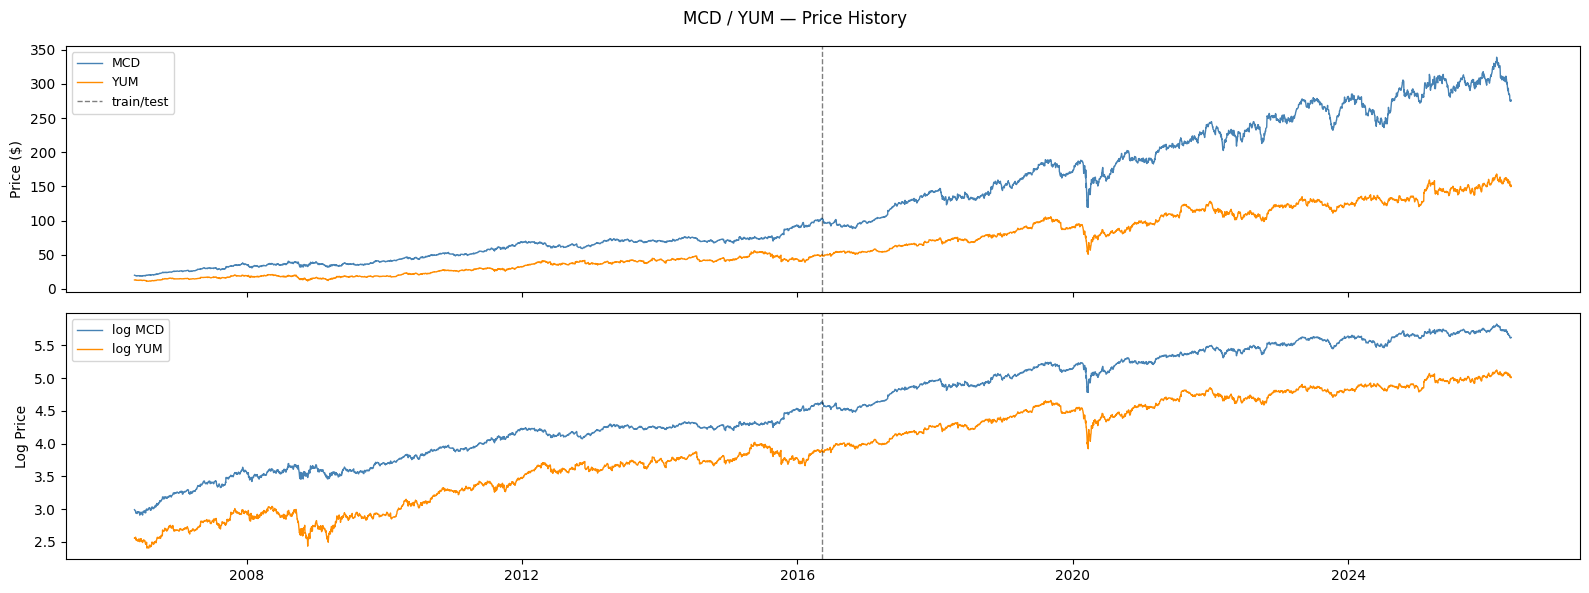

In [2]:
log_mcd = np.log(prices[0])
log_yum = np.log(prices[1])

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
fig.suptitle('MCD / YUM — Price History', fontsize=12)
ax = axes[0]
ax.plot(dates, prices[0], color='steelblue',  lw=1.0, label='MCD')
ax.plot(dates, prices[1], color='darkorange', lw=1.0, label='YUM')
ax.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.5, label='train/test')
ax.set_ylabel('Price ($)'); ax.legend(fontsize=9)
ax = axes[1]
ax.plot(dates, log_mcd, color='steelblue',  lw=1.0, label='log MCD')
ax.plot(dates, log_yum, color='darkorange', lw=1.0, label='log YUM')
ax.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.5)
ax.set_ylabel('Log Price'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

108 windows  |  ADF+HL: 19 pass  |  ADF+KPSS+HL: 12 pass


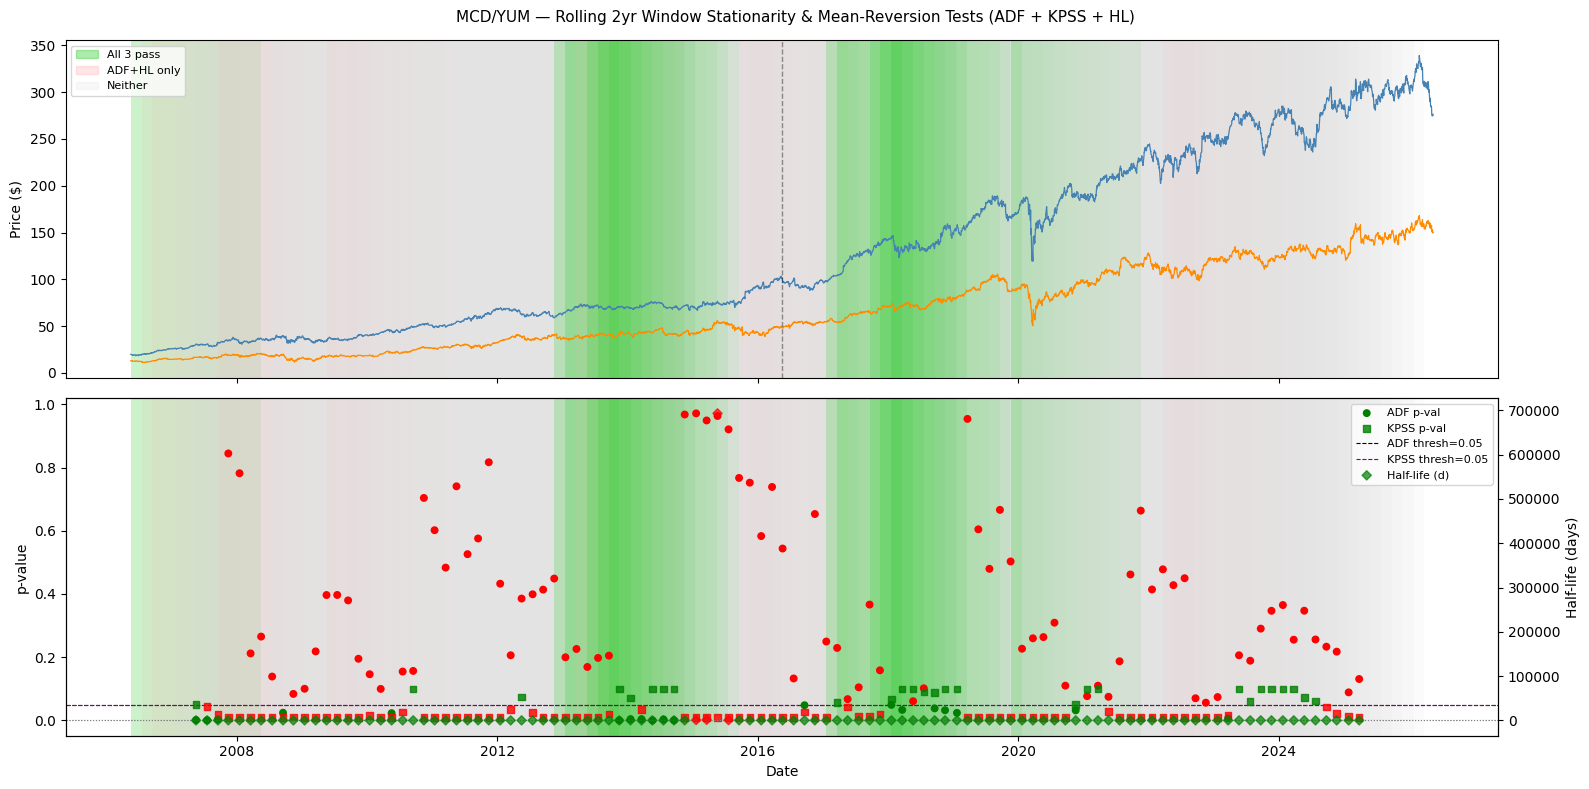


Start         End           Beta    ADF-p    KPSS-p   HL(d)    Pass
------------------------------------------------------------------------
2006-05-16    2008-05-15     1.192   0.0013   0.0506     11.2  ✓
2006-07-17    2008-07-16     1.112   0.0006   0.0438      9.3  ~
2006-09-14    2008-09-15     1.189   0.0030   0.0194     11.7  ~
2006-11-13    2008-11-12     0.899   0.8446   0.0100    105.2
2007-01-17    2009-01-14     0.541   0.7819   0.0100     91.8
2007-03-19    2009-03-17     0.289   0.2120   0.0100     40.5
2007-05-17    2009-05-15     0.167   0.2652   0.0100     31.3
2007-07-18    2009-07-16     0.166   0.1388   0.0100     24.3
2007-09-17    2009-09-15     0.101   0.0243   0.0100     12.1  ~
2007-11-14    2009-11-12     0.127   0.0838   0.0107     13.5
2008-01-16    2010-01-14     0.182   0.1001   0.0100     18.9
2008-03-18    2010-03-17     0.243   0.2184   0.0100     25.0
2008-05-16    2010-05-17     0.444   0.3967   0.0100     33.3
2008-07-17    2010-07-16     0.540   0.3

In [3]:
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats as scipy_stats
import warnings

WINDOW_DAYS = 504   # ~2 years of trading days
STEP_DAYS   = 42    # ~2 months

ADF_PVAL    = 0.05
KPSS_PVAL   = 0.05
HL_MIN      = 5
HL_MAX      = 252

def half_life(spread):
    y = spread[1:]; x = spread[:-1]
    b = np.clip(np.polyfit(x, y, 1)[0], 1e-6, 1 - 1e-6)
    return -np.log(2) / np.log(b)

results = []
starts  = list(range(0, N - WINDOW_DAYS + 1, STEP_DAYS))

for s in starts:
    e   = s + WINDOW_DAYS
    lA  = log_mcd[s:e]; lB = log_yum[s:e]
    slope, intercept, *_ = scipy_stats.linregress(lB, lA)
    spread = lA - slope * lB - intercept

    adf_p  = adfuller(spread, autolag='AIC')[1]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_p = kpss(spread, regression='c', nlags='auto')[1]
    hl = half_life(spread)

    adf_ok  = adf_p  < ADF_PVAL
    kpss_ok = kpss_p > KPSS_PVAL
    hl_ok   = HL_MIN < hl < HL_MAX
    both    = adf_ok and hl_ok
    all3    = adf_ok and kpss_ok and hl_ok

    results.append(dict(s=s, e=e, slope=slope,
                        adf_p=adf_p, kpss_p=kpss_p, hl=hl,
                        adf_ok=adf_ok, kpss_ok=kpss_ok, hl_ok=hl_ok,
                        both=both, all3=all3))

n_both = sum(r['both'] for r in results)
n_all3 = sum(r['all3'] for r in results)
print(f'{len(results)} windows  |  ADF+HL: {n_both} pass  |  ADF+KPSS+HL: {n_all3} pass')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('MCD/YUM — Rolling 2yr Window Stationarity & Mean-Reversion Tests (ADF + KPSS + HL)', fontsize=11)

ax0 = axes[0]
ax0.plot(dates, prices[0], color='steelblue',  lw=0.9, label='MCD')
ax0.plot(dates, prices[1], color='darkorange', lw=0.9, label='YUM')
ax0.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.4)
ax0.set_ylabel('Price ($)')

ax1 = axes[1]; ax1_r = ax1.twinx()

for r in results:
    colour = 'limegreen' if r['all3'] else ('#ffaaaa' if r['both'] else '#dddddd')
    alpha  = 0.25 if r['all3'] else 0.10
    for ax in axes:
        ax.axvspan(dates[r['s']], dates[r['e']-1], color=colour, alpha=alpha, lw=0)

mid_dates = [dates[(r['s'] + r['e']) // 2] for r in results]
ax1.scatter(mid_dates, [r['adf_p']  for r in results], s=22,
            color=['green' if r['adf_ok']  else 'red' for r in results], label='ADF p-val', zorder=3)
ax1.scatter(mid_dates, [r['kpss_p'] for r in results], s=22, marker='s',
            color=['green' if r['kpss_ok'] else 'red' for r in results], alpha=0.8, label='KPSS p-val', zorder=3)
ax1_r.scatter(mid_dates, [r['hl'] for r in results], s=22, marker='D',
              color=['green' if r['hl_ok'] else 'red' for r in results], alpha=0.7, label='Half-life (d)', zorder=3)

ax1.axhline(ADF_PVAL,  color='black',  lw=0.8, ls='--', label=f'ADF thresh={ADF_PVAL}')
ax1.axhline(KPSS_PVAL, color='purple', lw=0.8, ls='--', label=f'KPSS thresh={KPSS_PVAL}')
ax1_r.axhline(HL_MAX,  color='gray',   lw=0.8, ls=':')
ax1_r.axhline(HL_MIN,  color='gray',   lw=0.8, ls=':')
ax1.set_ylabel('p-value'); ax1_r.set_ylabel('Half-life (days)'); ax1.set_xlabel('Date')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1_r.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper right')

from matplotlib.patches import Patch
ax0.legend(handles=[Patch(color='limegreen', alpha=0.4, label='All 3 pass'),
                    Patch(color='#ffaaaa',   alpha=0.3, label='ADF+HL only'),
                    Patch(color='#dddddd',   alpha=0.2, label='Neither')],
           fontsize=8, loc='upper left')

plt.tight_layout(); plt.show()

print(f'\n{"Start":12s}  {"End":12s}  {"Beta":6s}  {"ADF-p":7s}  {"KPSS-p":7s}  {"HL(d)":7s}  Pass')
print('-' * 72)
for r in results:
    mark = '  ✓' if r['all3'] else ('  ~' if r['both'] else '')
    print(f'{str(dates[r["s"]].date()):12s}  {str(dates[r["e"]-1].date()):12s}  '
          f'{r["slope"]:6.3f}  {r["adf_p"]:7.4f}  {r["kpss_p"]:7.4f}  {r["hl"]:7.1f}{mark}')

/tmp/ipykernel_3700073/4283727814.py:10: RuntimeWarning: invalid value encountered in divide
  effective_beta = np.where(beta_count > 0, beta_sum / beta_count, 0.0)


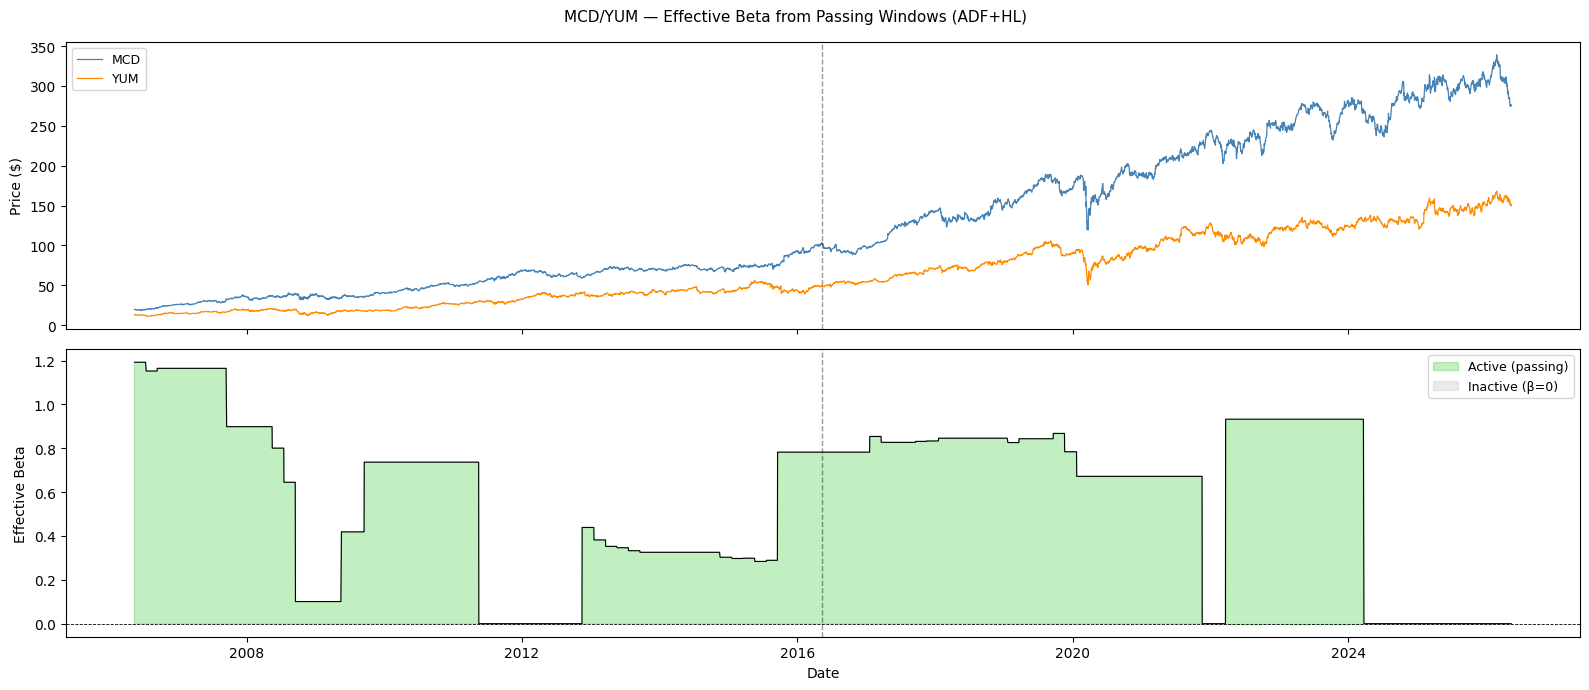

Active (β>0): 80.1% of all days
Beta range when active: [0.101, 1.192]
Mean beta when active: 0.714


In [4]:
# ── Effective beta: average over all passing windows containing each day ──
beta_sum   = np.zeros(N)
beta_count = np.zeros(N, dtype=int)

for r in results:
    if r['both']:
        beta_sum[r['s']:r['e']]   += r['slope']
        beta_count[r['s']:r['e']] += 1

effective_beta = np.where(beta_count > 0, beta_sum / beta_count, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('MCD/YUM — Effective Beta from Passing Windows (ADF+HL)', fontsize=11)

ax0 = axes[0]
ax0.plot(dates, prices[0], color='steelblue',  lw=0.9, label='MCD')
ax0.plot(dates, prices[1], color='darkorange', lw=0.9, label='YUM')
ax0.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.4)
ax0.set_ylabel('Price ($)'); ax0.legend(fontsize=9)

ax1 = axes[1]
active = effective_beta > 0
ax1.fill_between(dates, effective_beta, 0,
                 where=active,  color='limegreen', alpha=0.3, label='Active (passing)')
ax1.fill_between(dates, effective_beta, 0,
                 where=~active, color='#cccccc',   alpha=0.4, label='Inactive (β=0)')
ax1.plot(dates, effective_beta, color='black', lw=0.8)
ax1.axhline(0, color='black', lw=0.6, ls='--')
ax1.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.4)
ax1.set_ylabel('Effective Beta'); ax1.set_xlabel('Date')
ax1.legend(fontsize=9)

plt.tight_layout(); plt.show()

pct_active = 100 * active.mean()
print(f'Active (β>0): {pct_active:.1f}% of all days')
print(f'Beta range when active: [{effective_beta[active].min():.3f}, {effective_beta[active].max():.3f}]')
print(f'Mean beta when active: {effective_beta[active].mean():.3f}')

/tmp/ipykernel_3700073/3442052957.py:10: RuntimeWarning: invalid value encountered in divide
  effective_beta3 = np.where(beta_count3 > 0, beta_sum3 / beta_count3, 0.0)


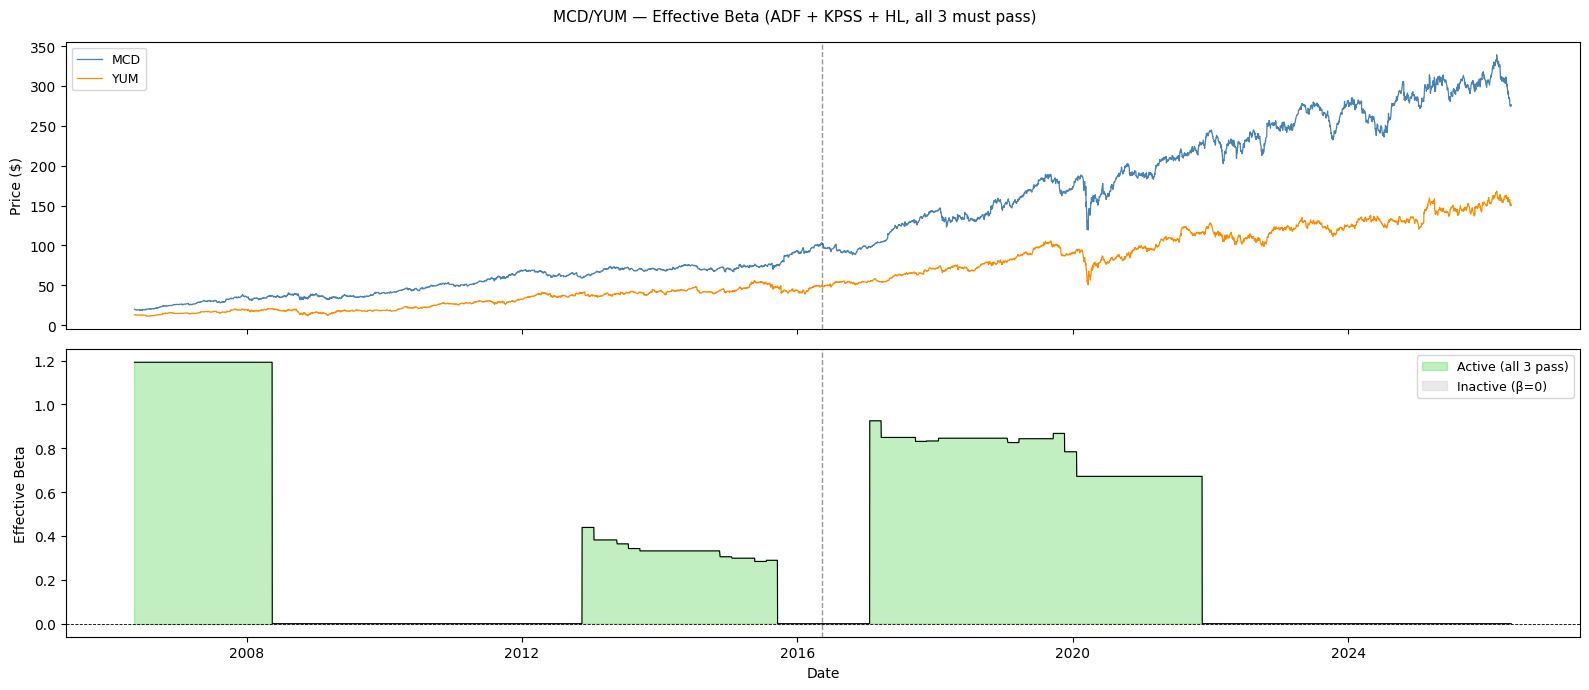

Active (β>0): 48.4% of all days
Beta range when active: [0.284, 1.192]
Mean beta when active:  0.735


In [5]:
# ── Strict beta: average over windows where ALL 3 tests pass ─────────────
beta_sum3   = np.zeros(N)
beta_count3 = np.zeros(N, dtype=int)

for r in results:
    if r['all3']:
        beta_sum3[r['s']:r['e']]   += r['slope']
        beta_count3[r['s']:r['e']] += 1

effective_beta3 = np.where(beta_count3 > 0, beta_sum3 / beta_count3, 0.0)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('MCD/YUM — Effective Beta (ADF + KPSS + HL, all 3 must pass)', fontsize=11)

ax0 = axes[0]
ax0.plot(dates, prices[0], color='steelblue',  lw=0.9, label='MCD')
ax0.plot(dates, prices[1], color='darkorange', lw=0.9, label='YUM')
ax0.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.4)
ax0.set_ylabel('Price ($)'); ax0.legend(fontsize=9)

ax1 = axes[1]
active3 = effective_beta3 > 0
ax1.fill_between(dates, effective_beta3, 0,
                 where=active3,  color='limegreen', alpha=0.3, label='Active (all 3 pass)')
ax1.fill_between(dates, effective_beta3, 0,
                 where=~active3, color='#cccccc',   alpha=0.4, label='Inactive (β=0)')
ax1.plot(dates, effective_beta3, color='black', lw=0.8)
ax1.axhline(0, color='black', lw=0.6, ls='--')
ax1.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.4)
ax1.set_ylabel('Effective Beta'); ax1.set_xlabel('Date')
ax1.legend(fontsize=9)

plt.tight_layout(); plt.show()

pct_active3 = 100 * active3.mean()
print(f'Active (β>0): {pct_active3:.1f}% of all days')
if active3.any():
    print(f'Beta range when active: [{effective_beta3[active3].min():.3f}, {effective_beta3[active3].max():.3f}]')
    print(f'Mean beta when active:  {effective_beta3[active3].mean():.3f}')

108 windows  |  ADF+KPSS+HL (Johansen): 15 pass


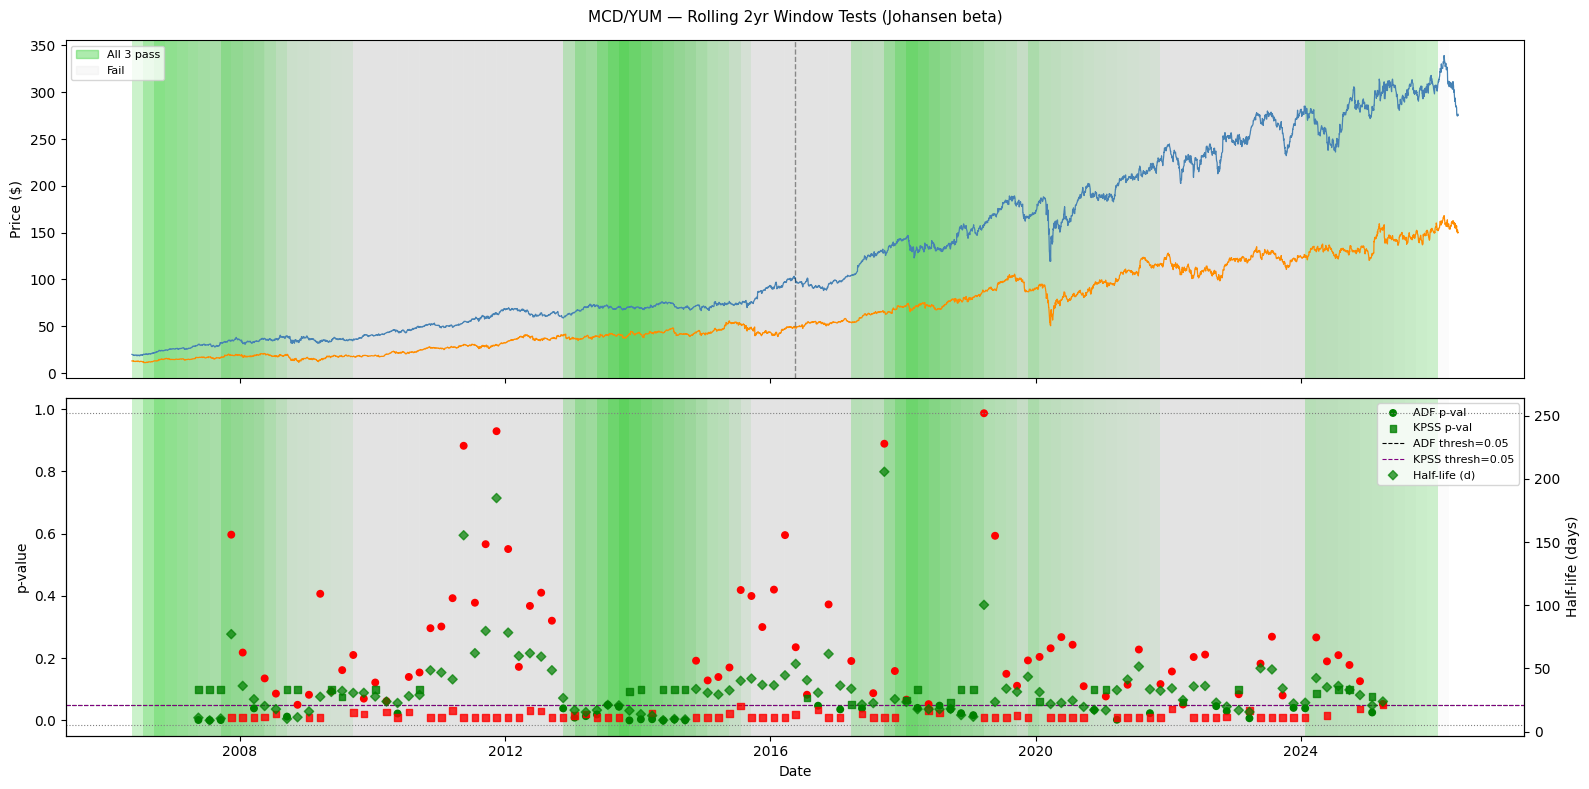


Start         End           Beta(J)  ADF-p    KPSS-p   HL(d)    Pass
--------------------------------------------------------------------------
2006-05-16    2008-05-15      1.224   0.0013   0.1000     11.0  ✓
2006-07-17    2008-07-16      1.209   0.0004   0.1000      8.9  ✓
2006-09-14    2008-09-15      1.393   0.0011   0.1000     10.3  ✓
2006-11-13    2008-11-12      0.507   0.5967   0.0100     77.1
2007-01-17    2009-01-14     -1.111   0.2180   0.0100     36.1
2007-03-19    2009-03-17     -0.257   0.0387   0.0100     25.6
2007-05-17    2009-05-15     -0.454   0.1349   0.0104     20.2
2007-07-18    2009-07-16     -0.246   0.0860   0.0205     17.7
2007-09-17    2009-09-15     -0.083   0.0122   0.1000     10.1  ✓
2007-11-14    2009-11-12     -0.066   0.0501   0.1000     11.3
2008-01-16    2010-01-14     -0.009   0.0824   0.0100     16.0
2008-03-18    2010-03-17      0.333   0.4067   0.0100     27.6
2008-05-16    2010-05-17      0.783   0.0936   0.1000     31.4
2008-07-17    2010-07-16

In [6]:
# ── Sliding window — Johansen beta ────────────────────────────────────────
from statsmodels.tsa.vector_ar.vecm import coint_johansen

results_j = []

for s in starts:
    e  = s + WINDOW_DAYS
    lA = log_mcd[s:e]; lB = log_yum[s:e]

    endog    = np.column_stack([lA, lB])
    res_j    = coint_johansen(endog, det_order=0, k_ar_diff=1)
    v        = res_j.evec[:, 0]
    slope_j  = -v[1] / v[0]
    spread_j = lA - slope_j * lB
    spread_j = spread_j - spread_j.mean()

    adf_p  = adfuller(spread_j, autolag='AIC')[1]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_p = kpss(spread_j, regression='c', nlags='auto')[1]
    hl = half_life(spread_j)

    adf_ok  = adf_p  < ADF_PVAL
    kpss_ok = kpss_p > KPSS_PVAL
    hl_ok   = HL_MIN < hl < HL_MAX
    all3    = adf_ok and kpss_ok and hl_ok

    results_j.append(dict(s=s, e=e, slope=slope_j,
                          adf_p=adf_p, kpss_p=kpss_p, hl=hl,
                          adf_ok=adf_ok, kpss_ok=kpss_ok, hl_ok=hl_ok,
                          all3=all3))

n_all3_j = sum(r['all3'] for r in results_j)
print(f'{len(results_j)} windows  |  ADF+KPSS+HL (Johansen): {n_all3_j} pass')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('MCD/YUM — Rolling 2yr Window Tests (Johansen beta)', fontsize=11)

ax0 = axes[0]
ax0.plot(dates, prices[0], color='steelblue',  lw=0.9, label='MCD')
ax0.plot(dates, prices[1], color='darkorange', lw=0.9, label='YUM')
ax0.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.4)
ax0.set_ylabel('Price ($)')

ax1 = axes[1]; ax1_r = ax1.twinx()

for r in results_j:
    colour = 'limegreen' if r['all3'] else '#dddddd'
    alpha  = 0.25 if r['all3'] else 0.10
    for ax in axes:
        ax.axvspan(dates[r['s']], dates[r['e']-1], color=colour, alpha=alpha, lw=0)

mid_dates = [dates[(r['s'] + r['e']) // 2] for r in results_j]
ax1.scatter(mid_dates, [r['adf_p']  for r in results_j], s=22,
            color=['green' if r['adf_ok']  else 'red' for r in results_j], label='ADF p-val', zorder=3)
ax1.scatter(mid_dates, [r['kpss_p'] for r in results_j], s=22, marker='s',
            color=['green' if r['kpss_ok'] else 'red' for r in results_j], alpha=0.8, label='KPSS p-val', zorder=3)
ax1_r.scatter(mid_dates, [r['hl'] for r in results_j], s=22, marker='D',
              color=['green' if r['hl_ok'] else 'red' for r in results_j], alpha=0.7, label='Half-life (d)', zorder=3)

ax1.axhline(ADF_PVAL,  color='black',  lw=0.8, ls='--', label=f'ADF thresh={ADF_PVAL}')
ax1.axhline(KPSS_PVAL, color='purple', lw=0.8, ls='--', label=f'KPSS thresh={KPSS_PVAL}')
ax1_r.axhline(HL_MAX,  color='gray',   lw=0.8, ls=':')
ax1_r.axhline(HL_MIN,  color='gray',   lw=0.8, ls=':')
ax1.set_ylabel('p-value'); ax1_r.set_ylabel('Half-life (days)'); ax1.set_xlabel('Date')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax1_r.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, fontsize=8, loc='upper right')

from matplotlib.patches import Patch
ax0.legend(handles=[Patch(color='limegreen', alpha=0.4, label='All 3 pass'),
                    Patch(color='#dddddd',   alpha=0.2, label='Fail')],
           fontsize=8, loc='upper left')

plt.tight_layout(); plt.show()

print(f'\n{"Start":12s}  {"End":12s}  {"Beta(J)":7s}  {"ADF-p":7s}  {"KPSS-p":7s}  {"HL(d)":7s}  Pass')
print('-' * 74)
for r in results_j:
    mark = '  ✓' if r['all3'] else ''
    print(f'{str(dates[r["s"]].date()):12s}  {str(dates[r["e"]-1].date()):12s}  '
          f'{r["slope"]:7.3f}  {r["adf_p"]:7.4f}  {r["kpss_p"]:7.4f}  {r["hl"]:7.1f}{mark}')

/tmp/ipykernel_3700073/3671423174.py:10: RuntimeWarning: invalid value encountered in divide
  eff_beta_j = np.where(beta_count_j > 0, beta_sum_j / beta_count_j, np.nan)


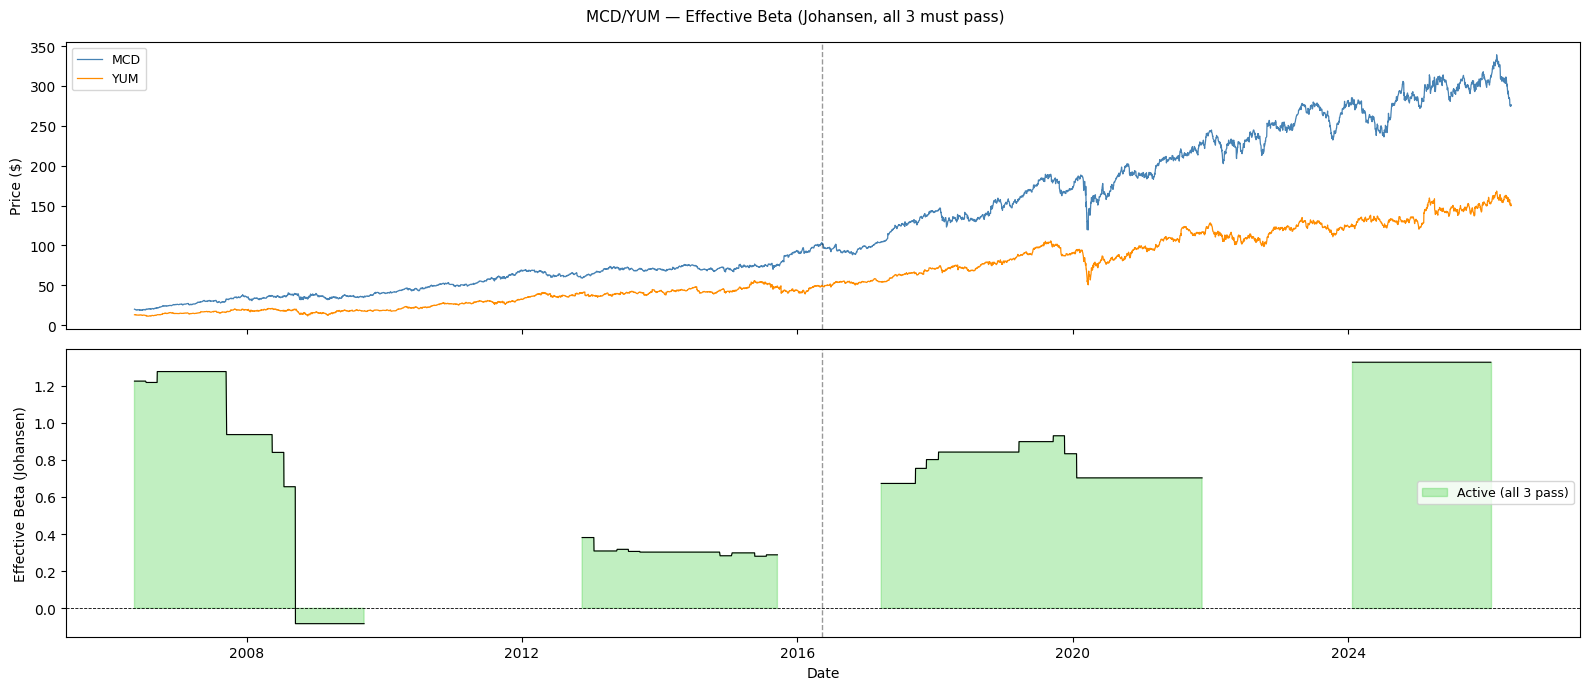

Active (β>0): 64.3% of all days
Beta range when active: [-0.083, 1.326]
Mean beta when active:  0.748


In [7]:
# ── Effective beta (Johansen, all 3 pass) ────────────────────────────────
beta_sum_j   = np.zeros(N)
beta_count_j = np.zeros(N, dtype=int)

for r in results_j:
    if r['all3']:
        beta_sum_j[r['s']:r['e']]   += r['slope']
        beta_count_j[r['s']:r['e']] += 1

eff_beta_j = np.where(beta_count_j > 0, beta_sum_j / beta_count_j, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('MCD/YUM — Effective Beta (Johansen, all 3 must pass)', fontsize=11)

ax0 = axes[0]
ax0.plot(dates, prices[0], color='steelblue',  lw=0.9, label='MCD')
ax0.plot(dates, prices[1], color='darkorange', lw=0.9, label='YUM')
ax0.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.4)
ax0.set_ylabel('Price ($)'); ax0.legend(fontsize=9)

ax1 = axes[1]
ax1.fill_between(dates, eff_beta_j, 0, color='limegreen', alpha=0.3, label='Active (all 3 pass)')
ax1.plot(dates, eff_beta_j, color='black', lw=0.8)
ax1.axhline(0, color='black', lw=0.6, ls='--')
ax1.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.4)
ax1.set_ylabel('Effective Beta (Johansen)'); ax1.set_xlabel('Date')
ax1.legend(fontsize=9)

plt.tight_layout(); plt.show()

active_j = ~np.isnan(eff_beta_j)
pct_j = 100 * active_j.mean()
print(f'Active (β>0): {pct_j:.1f}% of all days')
if active_j.any():
    print(f'Beta range when active: [{np.nanmin(eff_beta_j):.3f}, {np.nanmax(eff_beta_j):.3f}]')
    print(f'Mean beta when active:  {np.nanmean(eff_beta_j):.3f}')

## Spread from Averaged OLS Beta

Using the effective OLS beta (averaged across all 2-yr windows that pass ADF + KPSS + half-life). Inactive periods (no passing window covers that day) are left blank.

/tmp/ipykernel_3700073/2921852535.py:10: RuntimeWarning: invalid value encountered in divide
  eff_icp3    = np.where(beta_count3 > 0, icp_sum3 / beta_count3, np.nan)


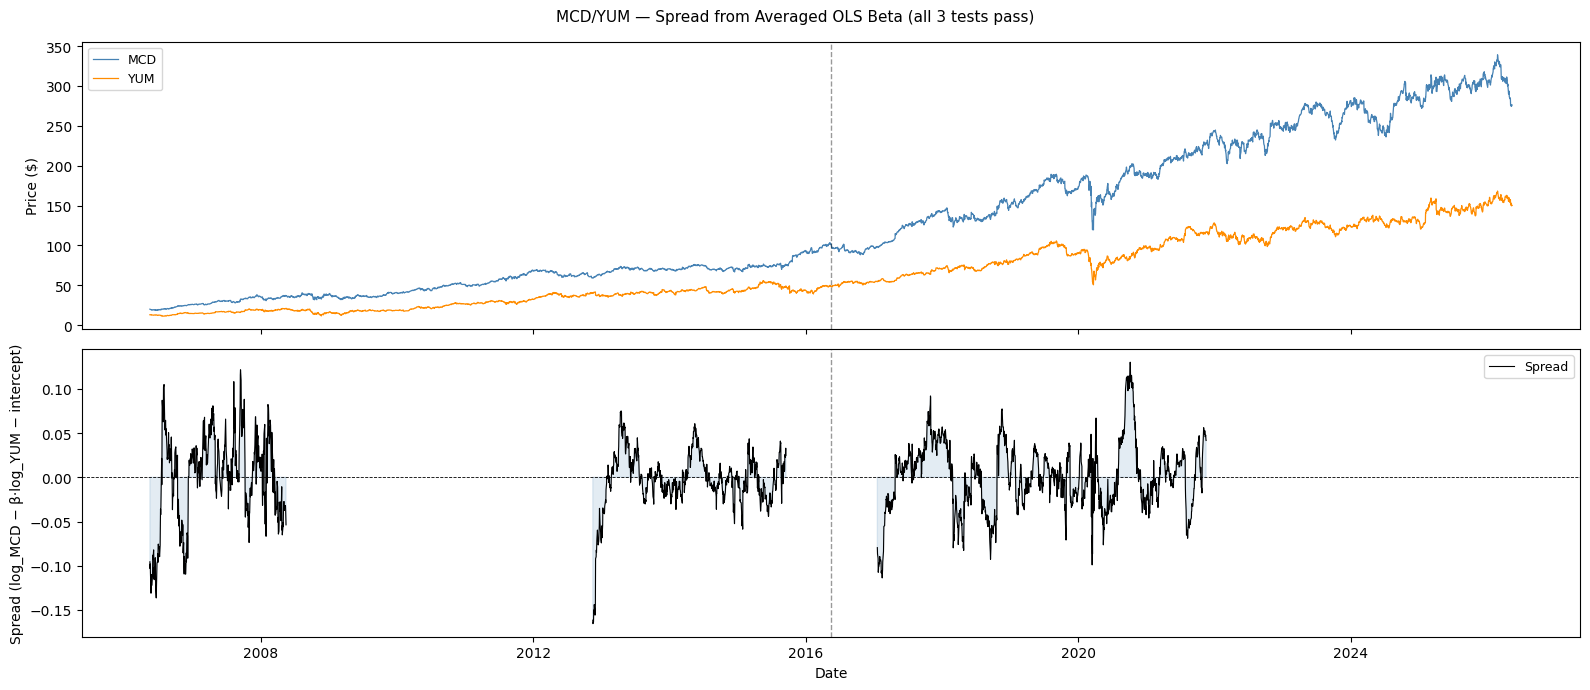

In [8]:
# ── Spread using averaged OLS beta+intercept from all-3-pass windows ─────
icp_sum3   = np.zeros(N)

for r in results:
    if r['all3']:
        s, e = r['s'], r['e']
        icp = log_mcd[s:e].mean() - r['slope'] * log_yum[s:e].mean()
        icp_sum3[s:e] += icp

eff_icp3    = np.where(beta_count3 > 0, icp_sum3 / beta_count3, np.nan)
eff_beta3_p = np.where(beta_count3 > 0, effective_beta3, np.nan)

spread3 = log_mcd - eff_beta3_p * log_yum - eff_icp3

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle('MCD/YUM — Spread from Averaged OLS Beta (all 3 tests pass)', fontsize=11)

ax0 = axes[0]
ax0.plot(dates, prices[0], color='steelblue',  lw=0.9, label='MCD')
ax0.plot(dates, prices[1], color='darkorange', lw=0.9, label='YUM')
ax0.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.4)
ax0.set_ylabel('Price ($)'); ax0.legend(fontsize=9)

ax1 = axes[1]
ax1.plot(dates, spread3, color='black', lw=0.8, label='Spread')
ax1.fill_between(dates, spread3, 0, color='steelblue', alpha=0.15)
ax1.axhline(0, color='black', lw=0.6, ls='--')
ax1.axvline(dates[train_end], color='black', lw=1, ls='--', alpha=0.4)
ax1.set_ylabel('Spread (log_MCD − β·log_YUM − intercept)')
ax1.set_xlabel('Date'); ax1.legend(fontsize=9)

plt.tight_layout(); plt.show()

## RL Agent — Stationary Spread with Dynamic Beta

Train a DDQN agent on synthetic episodes sampled exclusively from stationary windows (all 3 tests pass, beta defined at every timestep). The agent observes the precomputed spread and its rolling z-scores; the beta is assumed known and is used for position sizing. When beta changes (window boundaries), positions are rebalanced and TC is charged. When the pair leaves a stationary section the position is force-closed. Cash earns the risk-free rate (5% annualised) when flat.

In [9]:
import sys; sys.path.insert(0, '..')
from ddqn_v2 import DoubleDQN

RF_DAILY = (1.05) ** (1/252) - 1
_WINS    = (10, 45, 100)

def sharpe(W, rf=0.0):
    r = np.diff(W) / W[:-1]
    return float((r.mean() - rf) / (r.std() + 1e-12) * np.sqrt(252))

def ann_ret(W):
    return float((W[-1]/W[0]) ** (252/len(W)) - 1)

# ── Rolling z-scores on spread3 ───────────────────────────────────────────
_sp = pd.Series(spread3)
z3  = np.column_stack([
    ((_sp - _sp.rolling(w).mean()) / _sp.rolling(w).std().clip(lower=1e-8)).values
    for w in _WINS
])  # (N, 3)

valid3 = np.isfinite(spread3) & np.all(np.isfinite(z3), axis=1)

def _blocks(mask):
    out, i = [], 0
    while i < len(mask):
        if mask[i]:
            j = i + 1
            while j < len(mask) and mask[j]: j += 1
            out.append((i, j)); i = j
        else: i += 1
    return out

all_b = _blocks(valid3)
tr_b  = [(s, min(e, train_end)) for s, e in all_b if min(e, train_end) - s >= 252 and s < train_end]
te_b  = [(max(s, train_end), e) for s, e in all_b if e > train_end and e - max(s, train_end) >= 1]

print('Train blocks:')
for s, e in tr_b:  print(f'  {dates[s].date()} – {dates[e-1].date()}  ({e-s}d)')
print('Test blocks:')
for s, e in te_b:  print(f'  {dates[s].date()} – {dates[e-1].date()}  ({e-s}d)')


class StatSpreadEnv:
    """Obs: [spread, z10, z45, z100, position]. Zeros/flat when inactive."""
    def __init__(self, log_A, log_B, prices, spread, beta_arr, z_arr, valid_mask,
                 tc=0.0001, rf_daily=RF_DAILY, initial_wealth=10_000):
        self.log_A = log_A; self.log_B = log_B; self.prices = prices
        self.spread = spread; self.beta = beta_arr; self.z = z_arr
        self.valid  = valid_mask; self.tc = tc; self.rf = rf_daily
        self.W0 = float(initial_wealth); self.N = prices.shape[1]

    def _t(self):      return min(self._step, self.N - 1)
    def _wealth(self): return float(self._cash + self._sh @ self.prices[:, self._t()])

    def _obs(self):
        t = self._t()
        if not self.valid[t]:
            return np.zeros(5, dtype=np.float32)
        sp = float(self.spread[t])
        z  = np.where(np.isfinite(self.z[t]), self.z[t], 0.).astype(np.float32)
        return np.array([sp, z[0], z[1], z[2], float(self._pos)], dtype=np.float32)

    def _enter(self, direction):
        t = self._t(); b = float(self.beta[t]); p = self.prices[:, t]; C = self._wealth()
        d0 = C / (1 + b); d1 = b * C / (1 + b)
        self._sh[0] =  direction * d0 / p[0]
        self._sh[1] = -direction * d1 / p[1]
        self._cash  += direction * (d1 - d0) - self.tc * (d0 + d1)
        self._pos = direction; self._cur_b = b

    def _exit(self):
        t = self._t(); p = self.prices[:, t]
        self._cash  = self._wealth() - self.tc * (abs(self._sh[0]) * p[0] + abs(self._sh[1]) * p[1])
        self._sh[:] = 0.; self._pos = 0; self._cur_b = None

    def _rebal(self, new_b):
        t = self._t(); p = self.prices[:, t]; W = self._wealth()
        d0n = W / (1 + new_b); d1n = new_b * W / (1 + new_b)
        s0n =  self._pos * d0n / p[0]
        s1n = -self._pos * d1n / p[1]
        dn  = abs(s0n - self._sh[0]) * p[0] + abs(s1n - self._sh[1]) * p[1]
        self._cash  -= (s0n - self._sh[0]) * p[0] + (s1n - self._sh[1]) * p[1] + self.tc * dn
        self._sh[0] = s0n; self._sh[1] = s1n; self._cur_b = new_b

    def reset(self, t_start, ep_len):
        self._step = int(t_start); self._end = self._step + int(ep_len)
        self._cash = self.W0; self._sh = np.zeros(2); self._pos = 0; self._cur_b = None
        return self._obs()

    def step(self, action):
        desired = {0: 0, 1: 1, 2: -1}[int(action)]
        t = self._t(); active = bool(self.valid[t])
        if not active: desired = 0
        old_w = self._wealth()
        if desired != self._pos:
            if self._pos != 0:              self._exit()
            if desired != 0 and active:     self._enter(desired)
        elif self._pos != 0 and active:
            nb = float(self.beta[t])
            if nb != self._cur_b:           self._rebal(nb)
        if self._pos == 0:                  self._cash *= (1 + self.rf)
        self._step += 1
        done = self._step >= self._end
        return self._obs(), float(self._wealth() - old_w), done, False, {}

Train blocks:
  2006-10-05 – 2008-05-15  (405d)
  2013-04-11 – 2015-09-17  (615d)
Test blocks:
  2017-06-12 – 2021-11-17  (1119d)


In [10]:
# ── Real-data env + eval helpers ─────────────────────────────────────────
env        = StatSpreadEnv(log_mcd, log_yum, prices, spread3, eff_beta3_p, z3, valid3)
t_test_end = max(e for _, e in te_b) if te_b else train_end + 1

def eval_agent(t_start, t_end):
    obs   = env.reset(t_start, t_end - t_start)
    W     = [env._wealth()]; pos_hist = []; sp_hist = []
    done  = False
    while not done:
        t = env._t()
        sp_hist.append(float(spread3[t]) if valid3[t] else np.nan)
        act = agent.select_action(obs, deterministic=True)
        obs, _, done, _, _ = env.step(act)
        pos_hist.append(env._pos); W.append(env._wealth())
    if env._pos != 0:
        env._exit(); W[-1] = env._wealth()
    return np.array(W), np.array(pos_hist), np.array(sp_hist)

def quick_test():
    W, _, _ = eval_agent(train_end, t_test_end)
    tot = (W[-1] - W[0]) / W[0]
    return ann_ret(W), tot


# ── Fit helpers ───────────────────────────────────────────────────────────
def fit_ar1(sp):
    mu  = sp.mean()
    s_  = sp - mu
    phi = float(np.polyfit(s_[:-1], s_[1:], 1)[0])
    phi = np.clip(phi, 0.01, 0.9999)
    sig = float((s_[1:] - phi * s_[:-1]).std())
    return float(mu), phi, sig

def fit_gbm(lB):
    d = np.diff(lB)
    return float(d.mean()), float(d.std())


# ── Generate one synthetic episode ────────────────────────────────────────
def gen_episode(mu_s, phi, sig_s, s0, mu_B, sig_B, lB0, beta, icp, T, seed):
    rng = np.random.default_rng(seed)
    s = np.empty(T); s[0] = s0
    eps = rng.normal(0, sig_s, T - 1)
    for t in range(1, T):
        s[t] = mu_s + phi * (s[t - 1] - mu_s) + eps[t - 1]
    lB = np.empty(T); lB[0] = lB0
    eta = rng.normal(mu_B, sig_B, T - 1)
    for t in range(1, T):
        lB[t] = lB[t - 1] + eta[t - 1]
    lA = s + beta * lB + icp
    return np.row_stack([np.exp(lA), np.exp(lB)]), s


# ── Sample 200 real 18-month slices, generate 4 synthetic each → 800 ─────
TRADING_DAYS = 378
WARMUP       = max(_WINS)           # 100 days to fill z-score buffers
GEN_LEN      = TRADING_DAYS + WARMUP
N_REAL       = 200
N_SYN        = 4
SEED         = 42

rng_gen = np.random.default_rng(SEED)

valid_18m = [t0 for s, e in tr_b for t0 in range(s, e - GEN_LEN + 1)]
print(f'{len(valid_18m)} valid starts in training blocks '
      f'(need {GEN_LEN}d = {WARMUP}d warmup + {TRADING_DAYS}d trading)')

chosen = rng_gen.choice(len(valid_18m), size=N_REAL, replace=len(valid_18m) < N_REAL)

synthetic_eps = []
for k, idx in enumerate(chosen):
    t0  = valid_18m[idx]
    t1  = t0 + GEN_LEN
    sp  = spread3[t0:t1]
    lB  = log_yum[t0:t1]
    b   = float(np.nanmean(eff_beta3_p[t0:t1]))
    icp = float(np.nanmean(eff_icp3[t0:t1]))

    mu_s, phi, sig_s = fit_ar1(sp)
    mu_B, sig_B      = fit_gbm(lB)

    for j in range(N_SYN):
        p_syn, s_syn = gen_episode(
            mu_s, phi, sig_s, float(sp[0]),
            mu_B, sig_B, float(lB[0]),
            b, icp, GEN_LEN, seed=SEED + k * N_SYN + j
        )
        synthetic_eps.append((p_syn, s_syn, b))

print(f'{len(synthetic_eps)} synthetic episodes  |  '
      f'{GEN_LEN}d total  ({WARMUP}d warmup + {TRADING_DAYS}d trading)')

138 valid starts in training blocks (need 478d = 100d warmup + 378d trading)


/tmp/ipykernel_3700073/3359985472.py:51: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  return np.row_stack([np.exp(lA), np.exp(lB)]), s


800 synthetic episodes  |  478d total  (100d warmup + 378d trading)


In [11]:
# ── Synthetic episode environment ─────────────────────────────────────────
class SynEpisodeEnv:
    """Single fixed-length synthetic episode. Beta is constant (no rebalance)."""

    def __init__(self, prices, spread, beta, warmup, tc=0.0001, rf_daily=RF_DAILY, initial_wealth=10_000):
        self.prices  = prices.astype(np.float64)
        self.T       = prices.shape[1]
        self.warmup  = int(warmup)
        self.tc      = tc;  self.rf = rf_daily;  self.W0 = float(initial_wealth)
        self.beta    = float(beta)
        self._sp     = spread
        s = pd.Series(spread)
        self._z = np.column_stack([
            ((s - s.rolling(w).mean()) / s.rolling(w).std().clip(lower=1e-8)).values
            for w in _WINS
        ])  # (T, 3)

    def _t(self):      return min(self._step, self.T - 1)
    def _wealth(self): return float(self._cash + self._sh @ self.prices[:, self._t()])

    def _obs(self):
        t = self._t()
        z = np.where(np.isfinite(self._z[t]), self._z[t], 0.).astype(np.float32)
        return np.array([self._sp[t], z[0], z[1], z[2], float(self._pos)], dtype=np.float32)

    def _enter(self, d):
        t  = self._t(); b = self.beta; p = self.prices[:, t]; C = self._wealth()
        d0 = C/(1+b); d1 = b*C/(1+b)
        self._sh[0] =  d*d0/p[0]; self._sh[1] = -d*d1/p[1]
        self._cash += d*(d1-d0) - self.tc*(d0+d1); self._pos = d

    def _exit(self):
        t  = self._t(); p = self.prices[:, t]
        self._cash = self._wealth() - self.tc*(abs(self._sh[0])*p[0]+abs(self._sh[1])*p[1])
        self._sh[:] = 0.; self._pos = 0

    def reset(self):
        self._step = self.warmup; self._end = self.T
        self._cash = self.W0; self._sh = np.zeros(2); self._pos = 0
        return self._obs()

    def step(self, action):
        desired = {0:0, 1:1, 2:-1}[int(action)]
        old_w   = self._wealth()
        if desired != self._pos:
            if self._pos != 0: self._exit()
            if desired != 0:   self._enter(desired)
        if self._pos == 0: self._cash *= (1 + self.rf)
        self._step += 1
        done = self._step >= self._end
        return self._obs(), float(self._wealth() - old_w), done, False, {}


# ── Instantiate all 800 envs ──────────────────────────────────────────────
syn_envs = [SynEpisodeEnv(p, s, b, warmup=WARMUP) for p, s, b in synthetic_eps]
print(f'{len(syn_envs)} synthetic environments ready  ({TRADING_DAYS}d trading each)')

# ── DDQN agent ────────────────────────────────────────────────────────────
N_TRAIN    = 2000
LOG_EVERY  = 100
TRAIN_FREQ = 4

agent = DoubleDQN(state_dim=5, action_dim=3, hidden=64, lr=3e-4,
                  gamma=0.99, tau=0.005, buffer_size=int(2e5), batch_size=256,
                  eps_start=1.0, eps_end=0.05,
                  eps_decay_steps=N_TRAIN * TRADING_DAYS // 2, grad_clip=1.0)

rng_tr = np.random.default_rng(SEED + 1)
losses = []; steps = 0

for ep in range(N_TRAIN):
    env_ep = syn_envs[int(rng_tr.integers(0, len(syn_envs)))]
    obs    = env_ep.reset()
    done   = False

    while not done:
        act = agent.select_action(obs)
        obs2, r, done, _, _ = env_ep.step(act)
        agent.replay_buffer.add(obs.copy(), act, r, obs2.copy(), done)
        obs = obs2; steps += 1
        if steps % TRAIN_FREQ == 0:
            l = agent.train()
            if l is not None: losses.append(l)

    if (ep + 1) % LOG_EVERY == 0:
        avg_loss     = np.mean(losses[-500:]) if losses else float('nan')
        ann_r, tot_r = quick_test()
        print(f'ep {ep+1:4d}  eps={agent.epsilon:.3f}  '
              f'loss={avg_loss:.4f}  |  '
              f'test  ann={ann_r*100:+.2f}%  total={tot_r*100:+.2f}%')

print('Training done.')

800 synthetic environments ready  (378d trading each)
ep  100  eps=0.905  loss=18.3959  |  test  ann=+11.42%  total=+81.61%
ep  200  eps=0.810  loss=17.3785  |  test  ann=+13.39%  total=+100.07%
ep  300  eps=0.715  loss=17.0427  |  test  ann=+13.23%  total=+98.57%
ep  400  eps=0.620  loss=15.7737  |  test  ann=+12.54%  total=+91.98%
ep  500  eps=0.525  loss=15.3816  |  test  ann=+15.65%  total=+123.16%
ep  600  eps=0.430  loss=14.6492  |  test  ann=+16.65%  total=+134.00%
ep  700  eps=0.335  loss=14.1493  |  test  ann=+18.50%  total=+155.27%
ep  800  eps=0.240  loss=13.5170  |  test  ann=+18.75%  total=+158.16%
ep  900  eps=0.145  loss=12.8690  |  test  ann=+18.69%  total=+157.48%
ep 1000  eps=0.050  loss=12.6910  |  test  ann=+19.41%  total=+166.26%
ep 1100  eps=0.050  loss=11.7079  |  test  ann=+20.51%  total=+180.11%
ep 1200  eps=0.050  loss=11.1323  |  test  ann=+18.20%  total=+151.66%
ep 1300  eps=0.050  loss=10.2515  |  test  ann=+18.40%  total=+154.06%
ep 1400  eps=0.050  loss=9

Train: SR=1.937  ann=+13.91%  long=422d  short=468d  flat=1527d


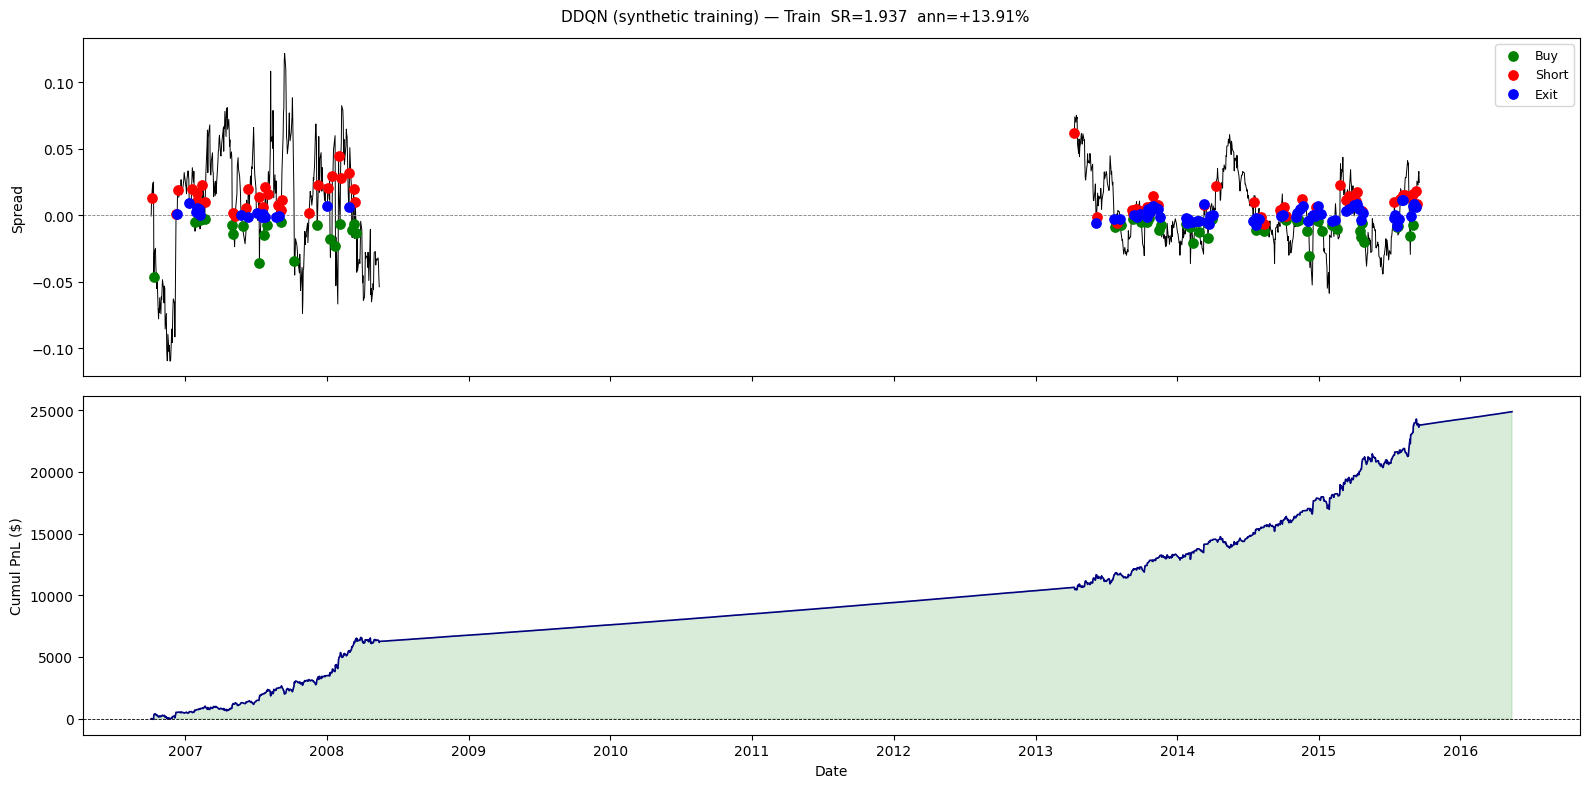

Test: SR=1.993  ann=+18.14%  long=460d  short=526d  flat=404d


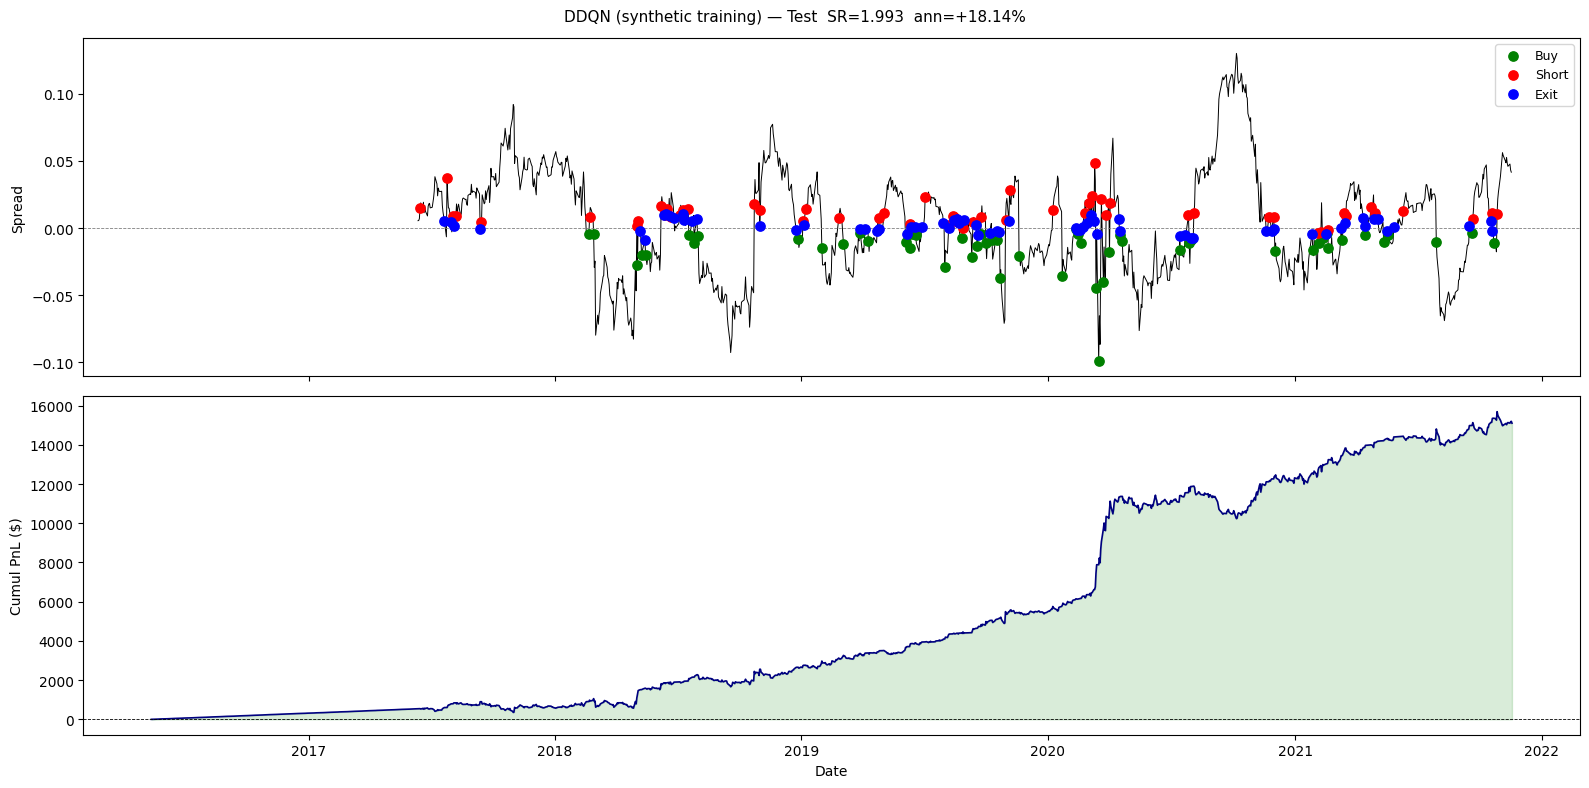

In [12]:
# ── Final evaluation on real data ─────────────────────────────────────────
for label, t0, t1 in [('Train', tr_b[0][0], train_end),
                       ('Test',  train_end,  t_test_end)]:
    W, pos, sp = eval_agent(t0, t1)
    T    = len(pos)
    prev = np.concatenate([[0], pos[:-1]])
    buy_i = np.where((pos ==  1) & (prev !=  1))[0]
    sh_i  = np.where((pos == -1) & (prev != -1))[0]
    ex_i  = np.where((pos ==  0) & (prev !=  0))[0]
    t_idx = dates[t0 : t0 + T]

    print(f'{label}: SR={sharpe(W):.3f}  ann={ann_ret(W)*100:+.2f}%  '
          f'long={int((pos==1).sum())}d  short={int((pos==-1).sum())}d  flat={int((pos==0).sum())}d')

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    fig.suptitle(f'DDQN (synthetic training) — {label}  '
                 f'SR={sharpe(W):.3f}  ann={ann_ret(W)*100:+.2f}%', fontsize=11)

    ax = axes[0]
    ax.plot(t_idx, sp, color='black', lw=0.7)
    ax.axhline(0, color='gray', lw=0.6, ls='--')
    if len(buy_i): ax.scatter(t_idx[buy_i], sp[buy_i], color='green', s=45, zorder=3, label='Buy')
    if len(sh_i):  ax.scatter(t_idx[sh_i],  sp[sh_i],  color='red',   s=45, zorder=3, label='Short')
    if len(ex_i):  ax.scatter(t_idx[ex_i],  sp[ex_i],  color='blue',  s=45, zorder=3, label='Exit')
    ax.set_ylabel('Spread'); ax.legend(fontsize=9)

    ax = axes[1]
    tw  = dates[t0 : t0 + T + 1]
    pnl = W - W[0]
    ax.plot(tw, pnl, color='navy', lw=1.2)
    ax.axhline(0, color='black', lw=0.6, ls='--')
    ax.fill_between(tw, pnl, 0, where=pnl >= 0, alpha=0.15, color='green')
    ax.fill_between(tw, pnl, 0, where=pnl <  0, alpha=0.15, color='red')
    ax.set_ylabel('Cumul PnL ($)'); ax.set_xlabel('Date')
    plt.tight_layout(); plt.show()